In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from tqdm.auto import tqdm
%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'

In [3]:
!wget $data -O data-lead-scoring.csv 

--2025-10-17 08:57:34--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘data-lead-scoring.csv’

data-lead-scoring.c 100%[===================>]  78.98K   237KB/s    in 0.3s    

2025-10-17 08:57:35 (237 KB/s) - ‘data-lead-scoring.csv’ saved [80876/80876]



In [4]:
df = pd.read_csv('data-lead-scoring.csv')
df.head().T

,0,1,2,3,4
lead_source,paid_ads,social_media,events,paid_ads,referral
industry,NaN,retail,healthcare,retail,education
number_of_courses_viewed,1,1,5,2,3
annual_income,79450.0,46992.0,78796.0,83843.0,85012.0
employment_status,unemployed,employed,unemployed,NaN,self_employed
location,south_america,south_america,australia,australia,europe
interaction_count,4,1,3,1,3
lead_score,0.94,0.8,0.69,0.87,0.62
converted,1,0,1,0,1


In [5]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']

In [6]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

In [7]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [8]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [9]:
len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [10]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [11]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

In [12]:
del df_train['converted']
del df_val['converted']
del df_test['converted']

### Q1: ROC AUC feature importance

In [13]:
for n in numerical:
    y_pred = df_train[n]
    auc_score = roc_auc_score(y_train, y_pred)
    print(n, auc_score)

number_of_courses_viewed 0.7635680590007088
annual_income 0.5519578313253012
interaction_count 0.738270176293409
lead_score 0.6144993577250176


### Q2: Training the model

In [14]:
def train_model(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [15]:
def predict(df, dv, model, threshold=None):
    dicts = df[categorical + numerical].to_dict(orient='records')
    X = dv.transform(dicts)
    y_proba = model.predict_proba(X)[:, 1]
    if threshold is not None:
        return (y_proba >= threshold).astype(int)
    else:
        return y_proba

In [16]:
dv, model = train_model(df_train, y_train)

In [17]:
y_pred = predict(df_val, dv, model)

In [18]:
auc_score = roc_auc_score(y_val, y_pred)
round(auc_score,2)

0.82

### Q3: Precision and Recall

In [19]:
thresholds = np.linspace(0,1,101)
pr_data = []
for t in thresholds:
    dv, model = train_model(df_train, y_train)
    y_pred = predict(df_val, dv, model, t)
    p_score = precision_score(y_val,y_pred)
    r_score = recall_score(y_val, y_pred)
    pr_data.append((t, p_score, r_score))

/opt/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [20]:
columns = ['threshold', 'p_score', 'r_score']
pr_df = pd.DataFrame(pr_data, columns=columns)
pr_df

,threshold,p_score,r_score
0,0.00,0.583618,1.000000
1,0.01,0.583618,1.000000
2,0.02,0.583618,1.000000
3,0.03,0.583618,1.000000
4,0.04,0.583618,1.000000
...,...,...,...
96,0.96,1.000000,0.017544
97,0.97,1.000000,0.005848
98,0.98,0.000000,0.000000
99,0.99,0.000000,0.000000


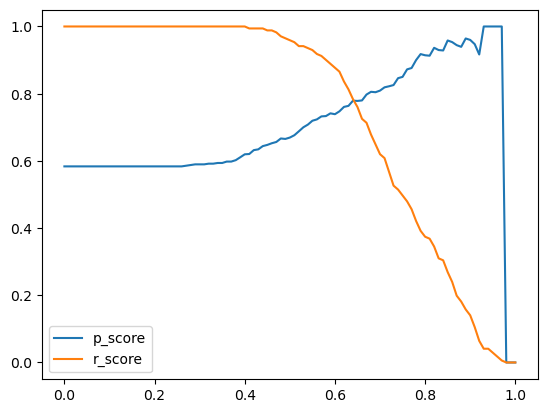

In [21]:
plt.plot(pr_df.threshold, pr_df['p_score'], label='p_score')
plt.plot(pr_df.threshold, pr_df['r_score'], label='r_score')
plt.legend()

In [22]:
pr_df[(pr_df.threshold <= 0.8) & (0.6 <= pr_df.threshold)]

,threshold,p_score,r_score
60,0.60,0.738916,0.877193
61,0.61,0.747475,0.865497
62,0.62,0.760638,0.836257
63,0.63,0.763736,0.812865
64,0.64,0.779070,0.783626
65,0.65,0.778443,0.760234
66,0.66,0.779874,0.725146
67,0.67,0.797386,0.713450
68,0.68,0.805556,0.678363
69,0.69,0.804348,0.649123


### Q4: F1 score

In [23]:
pr_df['f1_score'] = 2*(pr_df.p_score * pr_df.r_score) / (pr_df.p_score + pr_df.r_score)

In [24]:
pr_df

,threshold,p_score,r_score,f1_score
0,0.00,0.583618,1.000000,0.737069
1,0.01,0.583618,1.000000,0.737069
2,0.02,0.583618,1.000000,0.737069
3,0.03,0.583618,1.000000,0.737069
4,0.04,0.583618,1.000000,0.737069
...,...,...,...,...
96,0.96,1.000000,0.017544,0.034483
97,0.97,1.000000,0.005848,0.011628
98,0.98,0.000000,0.000000,NaN
99,0.99,0.000000,0.000000,NaN


In [25]:
pr_df[pr_df.f1_score == pr_df.f1_score.max()].threshold

57    0.57
Name: threshold, dtype: float64

### Q5: 5-Fold CV

In [26]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

In [27]:
def cross_validation_func(df, C=1.0):
    scores = []
    for train_idx, val_idx in kfold.split(df):
        df_train = df.iloc[train_idx]
        df_val = df.iloc[val_idx]
    
        y_train = df_train.converted.values
        y_val = df_val.converted.values
    
        del df_train['converted']
        del df_val['converted']
    
        dv, model = train_model(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    return scores
    

In [28]:
scores = cross_validation_func(df_full_train)
print('%.3f +- %.3f' %(np.mean(scores), np.std(scores)))

0.822 +- 0.036


### Q6: Hyperparameter Tuning

In [29]:
for C in tqdm([0.000001, 0.001, 1]):
    scores = cross_validation_func(df_full_train, C)
    print('C=%s auc=%.3f std=+-%.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/3 [00:00<?, ?it/s]

C=1e-06 auc=0.560 std=+-0.024
C=0.001 auc=0.867 std=+-0.029
C=1 auc=0.822 std=+-0.036
